# WCC high-contrast imaging of accreting protoplanets in H-alpha: feasibility

**Question.** Can the WCC detect the H-alpha emission of young, accreting planets (the PDS 70 b/c class)
next to their host star, and which of the three H-alpha filters in the WCC ETC (2, 6, 20 nm) does it best?

**Approach.** Everything runs through the WCC ETC instrument model (`wcc_etc`, via `wcc_sim`). The host
star is a Pickles template normalised in Gaia $G$; the planet is a pure emission line of fixed integrated
flux (the ETC's absolute-flux `emission` source). The stellar PSF is the ETC's jitter-blurred Airy pattern,
optionally degraded to a Strehl ratio $S<1$ with the core + halo model of
`jitter_strehl_sensitivity.ipynb`, plus the FRED scattered-light halo (`wcc_sim.scatter`). The host is kept
below saturation by stacking short frames. Two contrast metrics per separation:

1. **photon-noise 5σ contrast** after an ideal PSF subtraction: planet-to-star flux ratio at which the planet's
   aperture signal is 5x the photon + detector noise of the stellar light in that aperture;
2. **raw contrast**: planet flux equal to the stellar light in the same aperture, i.e. what it takes to see the
   planet as a bump on the wing with no subtraction at all.

Baseline PSF: jitter 10 mas (1σ per axis, the Lazuli config), $S = 1$. The requirement corner ($S = 0.8$ at r,
615 nm, which is $S = 0.82$ at 656 nm by Maréchal) is shown where it matters; the full jitter/Strehl
sensitivity is in `halpha_hci_jitter_strehl.ipynb`. Helpers live in `hci_psf.py` next to this notebook.

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

plt.style.use('gks')
warnings.filterwarnings('ignore')

from hci_psf import (Instrument, contrast_curve, aperture_fractions, strehl_at, HALO_K, OVERSAMPLE,
                     airy_fwhm_mas)

FILTERS = ['zwo:halpha2', 'zwo:halpha6', 'zwo:halpha20']
FLAB = {'zwo:halpha2': 'H-alpha 2 nm', 'zwo:halpha6': 'H-alpha 6 nm', 'zwo:halpha20': 'H-alpha 20 nm'}
TEAL, RED, AMBER, BLUE, GREEN, DBLUE = '#00798c', '#d1495b', '#edae49', '#30638e', '#66a182', '#003d5b'
FCOL = dict(zip(FILTERS, [TEAL, AMBER, RED]))
REQ_JIT, REQ_S_R = 10.0, 0.8
OUT = 'halpha_hci_out'
os.makedirs(OUT, exist_ok=True)

# ---- PDS 70 (the worked example; edit here) ---------------------------------------------------
HOST_SPT, HOST_G = 'K7V', 11.6          # PDS 70: K7IVe, Gaia G = 11.61 (Simbad), plx 8.90 mas -> 112 pc
HOST_HA_EW_A = 0.0                      # host's own H-alpha emission EW [A]; 0 = continuum only (see caveats)
# line fluxes [erg/s/cm^2] and projected separations [mas]; one source per number, see the PDS 70 section
PLANETS = {
    'b': dict(sep_mas=160.0, flux=8.1e-16, flux_lo=2.3e-16, flux_hi=1.6e-15),   # sep: Close+2025 (2023-24: 150-158 mas)
    'c': dict(sep_mas=210.0, flux=3.1e-16, flux_lo=2.0e-16, flux_hi=4.8e-16),   # sep: Close+2025 (2023-24: 207 mas)
}

def savefig(fig, name):
    fig.savefig(os.path.join(OUT, name + '.png'), dpi=200)
    fig.savefig(os.path.join(OUT, name + '.pdf'))

t0 = time.time()
INST = {f: Instrument(f, HOST_SPT, HOST_G) for f in FILTERS}
for inst in INST.values():
    inst.star_rate *= 1 + HOST_HA_EW_A / (10 * inst.band_eqw_nm)
S_REQ = float(strehl_at(REQ_S_R, INST['zwo:halpha2'].wavelength_m * 1e9))
i2 = INST['zwo:halpha2']
print(f'lambda_eff = {i2.wavelength_m * 1e9:.1f} nm, D = {i2.diameter_m:.3f} m, Airy FWHM = {i2.fwhm_mas:.1f} mas, '
      f'plate scale {i2.plate_mas:.2f} mas/px ({i2.fwhm_mas / i2.plate_mas:.2f} px/FWHM)')
print(f'S = {REQ_S_R} at 615 nm  ->  S = {S_REQ:.3f} at H-alpha;  setup {time.time() - t0:.1f} s')

lambda_eff = 656.3 nm, D = 3.065 m, Airy FWHM = 45.4 mas, plate scale 16.87 mas/px (2.69 px/FWHM)
S = 0.8 at 615 nm  ->  S = 0.822 at H-alpha;  setup 0.6 s


## 1. The three H-alpha filters

The planet is a line: its detected rate is the same in all three filters (the line sits inside each band).
The star is continuum: its rate scales with the filter's equivalent width. So the planet/star contrast
improves as 1/bandwidth, and the narrowest filter gives the biggest gain, provided its peak throughput
holds up. A second, less obvious win: the host saturates the 16 ke- IMX455 well quickly, so the frame time
is set by the star's peak pixel and the narrow filter allows longer frames, fewer reads, less read noise.

host K7V G = 11.6; planet line 1e-16 erg/s/cm^2; frame time = half well at 10 mas, S = 1
    filter    eqw_nm  star_e_s line_1e16_e_s contrast_1e16 sky_e_s_px t_frame_s frames_per_hour
------------- ------ --------- ------------- ------------- ---------- --------- ---------------
 H-alpha 2 nm   2.00 1.231e+04         0.870      7.07e-05   1.57e-04      7.57             475
 H-alpha 6 nm   5.97 3.783e+04         0.870      2.30e-05   4.87e-04      2.46            1462
H-alpha 20 nm  19.38 1.233e+05         0.870      7.05e-06   1.68e-03      0.75            4768

check: contrast gain 2 nm / 20 nm = 10.02  vs  EW ratio 9.69


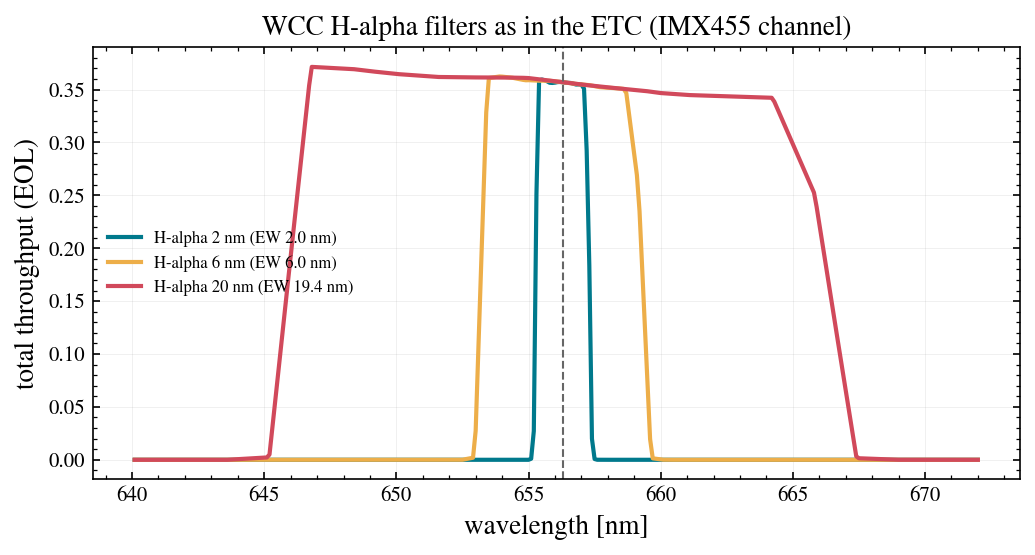

In [2]:
fig, ax = plt.subplots(figsize=(7, 3.8))
for f in FILTERS:
    bp = INST[f].sim.sensor.bandpass
    w = bp.waveset.value / 10
    m = (w > 640) & (w < 672)
    ax.plot(w[m], bp(bp.waveset)[m].value, color=FCOL[f], label=f'{FLAB[f]} (EW {INST[f].band_eqw_nm:.1f} nm)')
ax.axvline(656.3, color='0.4', ls='--', lw=1)
ax.set_xlabel('wavelength [nm]'); ax.set_ylabel('total throughput (EOL)'); ax.legend(fontsize=8)
ax.set_title('WCC H-alpha filters as in the ETC (IMX455 channel)')
fig.tight_layout(); savefig(fig, 'fig01_filters')

rows = []
for f in FILTERS:
    inst = INST[f]
    lr = inst.line_rate(1e-16)
    tf = inst.frame_time(REQ_JIT, 1.0)
    rows.append(dict(filter=FLAB[f], eqw_nm=inst.band_eqw_nm, star_e_s=inst.star_rate, line_1e16_e_s=lr,
                     contrast_1e16=lr / inst.star_rate, sky_e_s_px=inst.sky_rate, t_frame_s=tf,
                     frames_per_hour=3600 / tf))
FT = Table(rows)
for c, fmt in [('eqw_nm', '%.2f'), ('star_e_s', '%.4g'), ('line_1e16_e_s', '%.3f'), ('contrast_1e16', '%.2e'),
               ('sky_e_s_px', '%.2e'), ('t_frame_s', '%.2f'), ('frames_per_hour', '%.0f')]:
    FT[c].format = fmt
FT.write(os.path.join(OUT, 'filters.ecsv'), format='ascii.ecsv', overwrite=True)
print(f'host {HOST_SPT} G = {HOST_G}; planet line 1e-16 erg/s/cm^2; frame time = half well at 10 mas, S = 1')
FT.pprint(max_width=200)
g = FT['contrast_1e16'][0] / FT['contrast_1e16'][2]
print(f'\ncheck: contrast gain 2 nm / 20 nm = {g:.2f}  vs  EW ratio {FT["eqw_nm"][2] / FT["eqw_nm"][0]:.2f}')
assert abs(g / (FT['eqw_nm'][2] / FT['eqw_nm'][0]) - 1) < 0.1

## 2. The host star's PSF at 656 nm

Radial profile of the PDS 70 host in the 2 nm filter, in e-/s per detector pixel, for the baseline PSF, the
requirement-corner Strehl, and the FRED scattered-light halo. Two things to notice:

* At 656 nm the Airy core is 45 mas FWHM (2.7 px). PDS 70 b at 160 mas sits 3.5 Airy FWHM out, where the
  jitter-smeared Airy wing is a few $10^{-5}$ of the total flux per pixel (printed below): bright, but
  photon-noise-countable. The PSF is the ETC's unobscured circular-aperture Airy pattern; a central
  obstruction would raise the ring envelope at these separations.
* The FRED halo is tabulated on 0.4 mm cells (106 px) and is held flat inside 85 px (1.4"); its level there
  is $2\times10^{-10}$ per pixel, five to six orders of magnitude below the Airy wing at 0.1-0.5". Whether
  it is achromatic or scales as $\lambda^{-2}$ makes no difference in this zone, so the two are plotted but
  the rest of the notebook uses the as-is (conservative) halo. What the FRED map cannot tell us is whether
  the *near-core* scatter (micro-roughness, particulates) rises above this floor inside 1"; that is a
  stray-light question for the engineering team (see caveats).

HST cross-check: planet/star ratio in F656N observed 1.37e-03, ETC host model predicts 1.30e-03 (ratio 0.94; the HST value includes the host H-alpha line, the ETC does not)


PDS 70 b at 160 mas: Airy wing 1.12e-04 of total per px = 1.37 e-/s/px; FRED halo 2.3e-10 per px
PDS 70 c at 210 mas: Airy wing 6.05e-05 of total per px = 0.74 e-/s/px; FRED halo 2.3e-10 per px


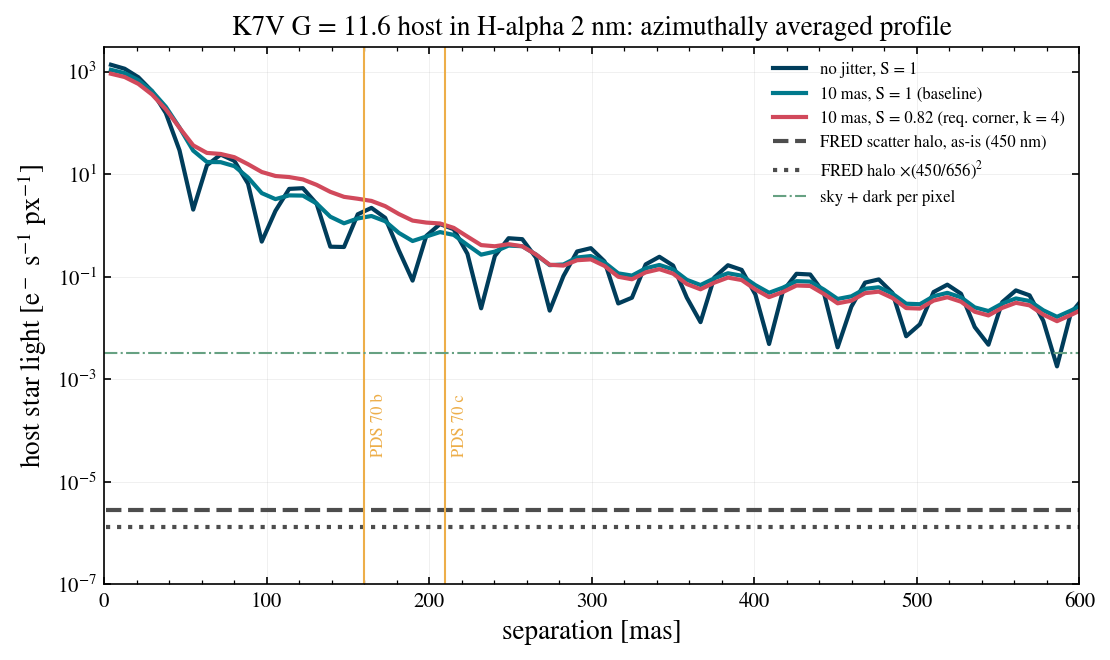

In [3]:
def radial_profile_px(psf_fine, plate_mas, dr_px=0.5):
    n = psf_fine.shape[0]; c = (n - 1) / 2
    yy, xx = np.mgrid[:n, :n]
    r = np.hypot(xx - c, yy - c) / OVERSAMPLE            # detector px
    edges = np.arange(0, r.max(), dr_px)
    idx = np.digitize(r.ravel(), edges) - 1
    p = psf_fine.ravel() * OVERSAMPLE ** 2               # per detector-pixel fraction, sampled finely
    prof = np.bincount(idx, weights=p, minlength=edges.size) / np.maximum(np.bincount(idx, minlength=edges.size), 1)
    return (edges[:-1] + dr_px / 2) * plate_mas, prof[:-1]

inst = i2
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for j, s, col, lab in [(0.0, 1.0, DBLUE, 'no jitter, S = 1'), (REQ_JIT, 1.0, TEAL, f'{REQ_JIT:.0f} mas, S = 1 (baseline)'),
                       (REQ_JIT, S_REQ, RED, f'{REQ_JIT:.0f} mas, S = {S_REQ:.2f} (req. corner, k = {HALO_K:.0f})')]:
    r, p = radial_profile_px(inst.fine_psf(j, s), inst.plate_mas)
    ax.plot(r, p * inst.star_rate, color=col, label=lab)
rr = np.linspace(1, 600, 300)
halo = inst.halo.profile(rr / inst.plate_mas) * inst.star_rate
ax.plot(rr, halo, color='0.3', ls='--', label='FRED scatter halo, as-is (450 nm)')
ax.plot(rr, halo * (450 / 656.3) ** 2, color='0.3', ls=':', label=r'FRED halo $\times(450/656)^2$')
for name, pl in PLANETS.items():
    ax.axvline(pl['sep_mas'], color=AMBER, lw=1)
    ax.text(pl['sep_mas'] + 4, 3e-5, f'PDS 70 {name}', color=AMBER, fontsize=8, rotation=90, va='bottom')
# host cross-check against HST: planet/star ratio in WFC3 F656N (17.7 A wide; Zhou et al. 2021)
F656N_W_A, F_B_HST, F_STAR_HST = 17.66, 1.62e-15, 1.18e-12
ratio_hst = F_B_HST / F_STAR_HST
ratio_etc = inst.line_rate(F_B_HST) / inst.star_rate * (10 * inst.band_eqw_nm) / F656N_W_A
print(f'HST cross-check: planet/star ratio in F656N observed {ratio_hst:.2e}, ETC host model predicts {ratio_etc:.2e} '
      f'(ratio {ratio_etc / ratio_hst:.2f}; the HST value includes the host H-alpha line, the ETC does not)')
assert abs(ratio_etc / ratio_hst - 1) < 0.3
ax.axhline(inst.sky_rate + inst.dark_rate, color=GREEN, ls='-.', lw=1, label='sky + dark per pixel')
ax.set_yscale('log'); ax.set_ylim(1e-7, 3e3); ax.set_xlim(0, 600)
ax.set_xlabel('separation [mas]'); ax.set_ylabel('host star light [e$^-$ s$^{-1}$ px$^{-1}$]')
ax.set_title(f'{HOST_SPT} G = {HOST_G} host in {FLAB["zwo:halpha2"]}: azimuthally averaged profile')
ax.legend(fontsize=8, loc='upper right'); fig.tight_layout(); savefig(fig, 'fig02_host_profile')

r, p = radial_profile_px(inst.fine_psf(REQ_JIT, 1.0), inst.plate_mas)
for name, pl in PLANETS.items():
    k = np.argmin(np.abs(r - pl['sep_mas']))
    print(f"PDS 70 {name} at {pl['sep_mas']:.0f} mas: Airy wing {p[k]:.2e} of total per px = {p[k] * inst.star_rate:.2f} e-/s/px; "
          f"FRED halo {inst.halo.profile(pl['sep_mas'] / inst.plate_mas):.1e} per px")

## 3. Contrast curves

For each separation and filter the aperture radius (1-3 px) is re-optimised for the best photon-limited
contrast, as an observer would. The stellar light in the aperture is azimuthally averaged over 12 position
angles. Noise terms: stellar photons in the aperture, sky + dark, and read noise from every frame in the
stack (frame time = half the well on the star's peak pixel). The reference PSF is assumed noise-free
(an ideal model or a much longer reference stack); a reference of equal depth would add the stellar term
once more.

9 contrast curves in 1 s


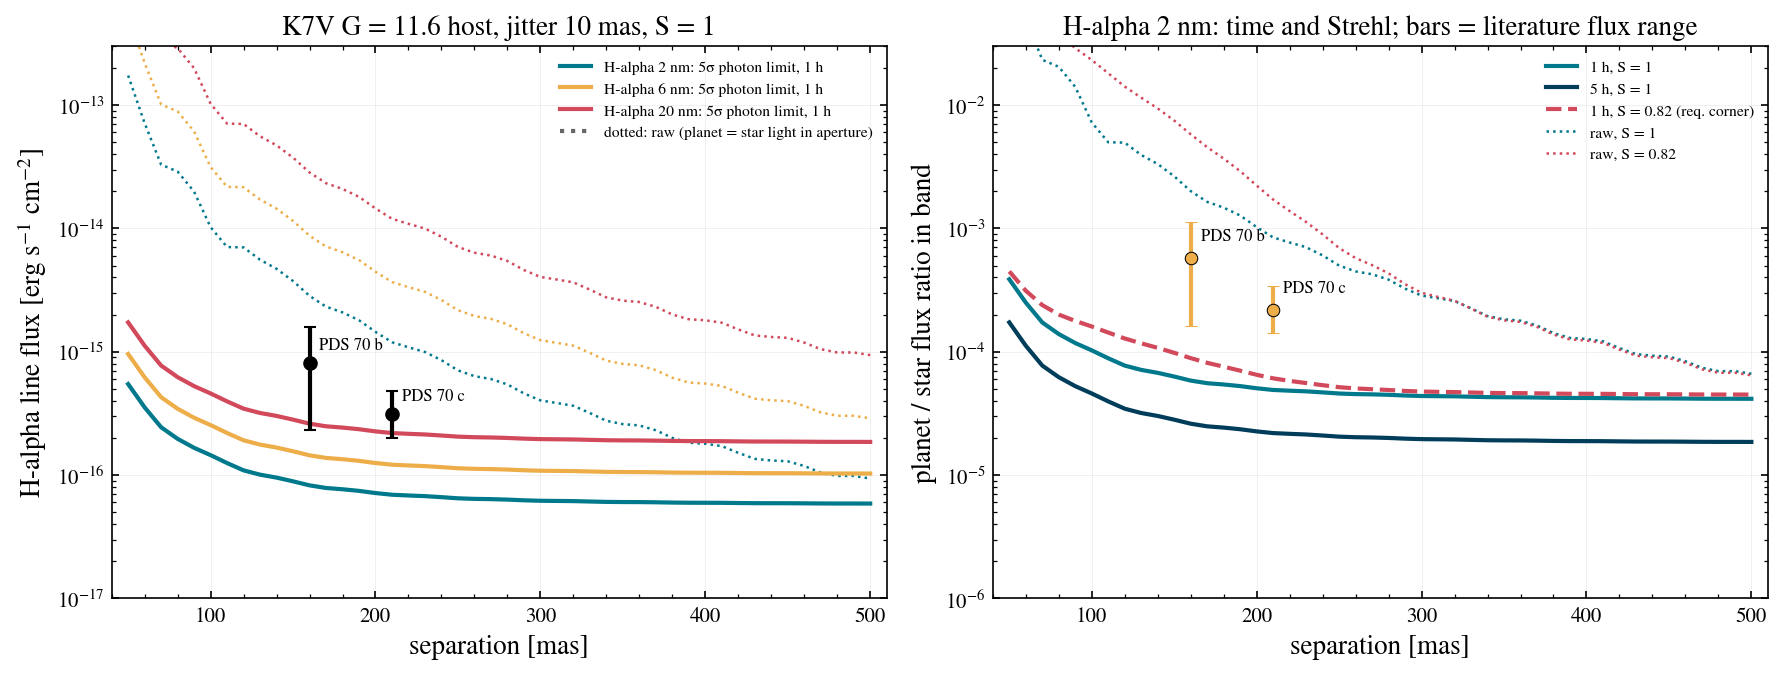

In [4]:
SEPS = np.arange(50.0, 501.0, 10.0)
TIMES = [3600.0, 5 * 3600.0]
CC = {}
t0 = time.time()
for f in FILTERS:
    for T in TIMES:
        CC[f, T, 1.0] = contrast_curve(INST[f], REQ_JIT, 1.0, SEPS, T)
    CC[f, 3600.0, S_REQ] = contrast_curve(INST[f], REQ_JIT, S_REQ, SEPS, 3600.0)
print(f'{len(CC)} contrast curves in {time.time() - t0:.0f} s')

rows = []
for (f, T, s), cc in CC.items():
    for k in range(SEPS.size):
        rows.append(dict(filter=FLAB[f], total_time_s=T, strehl=s, sep_mas=SEPS[k], contrast_5sig=cc['contrast'][k],
                         raw_contrast=cc['raw'][k], r_ap_px=cc['r_ap_px'][k], t_frame_s=cc['t_frame_s'],
                         n_frames=cc['n_frames']))
Table(rows).write(os.path.join(OUT, 'contrast_curves.ecsv'), format='ascii.ecsv', overwrite=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
# filter comparison in absolute line flux: "planet/star ratio" is not comparable between bands
for f in FILTERS:
    inst = INST[f]; cc = CC[f, 3600.0, 1.0]
    per_1e16 = inst.line_rate(1e-16) / inst.star_rate
    ax.plot(SEPS, cc['contrast'] / per_1e16 * 1e-16, color=FCOL[f], label=f'{FLAB[f]}: 5σ photon limit, 1 h')
    ax.plot(SEPS, cc['raw'] / per_1e16 * 1e-16, color=FCOL[f], ls=':', lw=1.2)
ax.plot([], [], color='0.4', ls=':', label='dotted: raw (planet = star light in aperture)')
for name, pl in PLANETS.items():
    ax.errorbar(pl['sep_mas'], pl['flux'], yerr=[[pl['flux'] - pl['flux_lo']], [pl['flux_hi'] - pl['flux']]],
                fmt='o', color='k', ms=6, capsize=3)
    ax.text(pl['sep_mas'] + 6, pl['flux'] * 1.3, f'PDS 70 {name}', fontsize=8)
ax.set_yscale('log'); ax.set_xlim(40, 510); ax.set_ylim(1e-17, 3e-13)
ax.set_xlabel('separation [mas]'); ax.set_ylabel('H-alpha line flux [erg s$^{-1}$ cm$^{-2}$]')
ax.set_title(f'{HOST_SPT} G = {HOST_G} host, jitter 10 mas, S = 1'); ax.legend(fontsize=7.5, loc='upper right')

ax = axes[1]
f = 'zwo:halpha2'
ax.plot(SEPS, CC[f, 3600.0, 1.0]['contrast'], color=TEAL, label='1 h, S = 1')
ax.plot(SEPS, CC[f, 5 * 3600.0, 1.0]['contrast'], color=DBLUE, label='5 h, S = 1')
ax.plot(SEPS, CC[f, 3600.0, S_REQ]['contrast'], color=RED, ls='--', label=f'1 h, S = {S_REQ:.2f} (req. corner)')
ax.plot(SEPS, CC[f, 3600.0, 1.0]['raw'], color=TEAL, ls=':', lw=1.2, label='raw, S = 1')
ax.plot(SEPS, CC[f, 3600.0, S_REQ]['raw'], color=RED, ls=':', lw=1.2, label=f'raw, S = {S_REQ:.2f}')
for name, pl in PLANETS.items():
    c = INST[f].line_rate(pl['flux']) / INST[f].star_rate
    ax.errorbar(pl['sep_mas'], c, yerr=[[c - INST[f].line_rate(pl['flux_lo']) / INST[f].star_rate],
                                        [INST[f].line_rate(pl['flux_hi']) / INST[f].star_rate - c]],
                fmt='o', color=AMBER, ms=6, mec='k', mew=0.5, capsize=3)
    ax.text(pl['sep_mas'] + 6, c * 1.4, f'PDS 70 {name}', fontsize=8)
ax.set_yscale('log'); ax.set_xlim(40, 510); ax.set_ylim(1e-6, 3e-2)
ax.set_xlabel('separation [mas]'); ax.set_ylabel('planet / star flux ratio in band')
ax.set_title(f'{FLAB[f]}: time and Strehl; bars = literature flux range'); ax.legend(fontsize=7.5, loc='upper right')
fig.tight_layout(); savefig(fig, 'fig03_contrast_curves')

In [5]:
# noise budget at the PDS 70 b separation, 1 h, baseline PSF
SEP_B = PLANETS['b']['sep_mas']
print(f'variance budget in the optimal aperture at {SEP_B:.0f} mas, 1 h, jitter 10 mas, S = 1:')
for f in FILTERS:
    inst = INST[f]; cc = CC[f, 3600.0, 1.0]
    k = np.argmin(np.abs(SEPS - SEP_B)); r_ap = cc['r_ap_px'][k]
    sfrac, pfrac = aperture_fractions(inst, inst.fine_psf(REQ_JIT, 1.0), [SEP_B], r_ap)
    T = 3600.0; n_pix = np.pi * r_ap ** 2
    star = inst.star_rate * sfrac[0] * T; sky = (inst.sky_rate + inst.dark_rate) * n_pix * T
    rn = cc['n_frames'] * inst.read_noise ** 2 * n_pix; tot = star + sky + rn
    print(f"  {FLAB[f]:14s}: r_ap {r_ap:.1f} px, EE {pfrac:.2f}, frame {cc['t_frame_s']:.2f} s x {cc['n_frames']} frames; "
          f"variance: star {star / tot:.2f}, sky+dark {sky / tot:.2f}, read {rn / tot:.2f}; "
          f"5σ contrast {cc['contrast'][k]:.2e}, raw {cc['raw'][k]:.2e}")

# sensitivity of the 2 nm photon limit to the detector assumptions (gain mode trades well depth against read noise)
inst = i2; base = contrast_curve(inst, REQ_JIT, 1.0, [SEP_B], 3600.0)['contrast'][0]
alt = {}
for label, rn, wf in [('read noise 1.5 e-', 1.5, 0.5), ('read noise 5 e-', 5.0, 0.5), ('frames to 80% well', inst.read_noise, 0.8)]:
    rn0 = inst.read_noise; inst.read_noise = rn
    alt[label] = contrast_curve(inst, REQ_JIT, 1.0, [SEP_B], 3600.0, well_fraction=wf)['contrast'][0] / base
    inst.read_noise = rn0
print('2 nm photon limit relative to the default (3.0 e- read noise, half well):', {k: f'{v:.2f}' for k, v in alt.items()})

variance budget in the optimal aperture at 160 mas, 1 h, jitter 10 mas, S = 1:
  H-alpha 2 nm  : r_ap 2.0 px, EE 0.65, frame 7.57 s x 476 frames; variance: star 0.51, sky+dark 0.00, read 0.49; 5σ contrast 5.84e-05, raw 2.01e-03
  H-alpha 6 nm  : r_ap 2.0 px, EE 0.65, frame 2.46 s x 1463 frames; variance: star 0.51, sky+dark 0.00, read 0.49; 5σ contrast 3.33e-05, raw 2.01e-03
  H-alpha 20 nm : r_ap 2.0 px, EE 0.65, frame 0.75 s x 4769 frames; variance: star 0.51, sky+dark 0.00, read 0.49; 5σ contrast 1.84e-05, raw 2.00e-03


2 nm photon limit relative to the default (3.0 e- read noise, half well): {'read noise 1.5 e-': '0.79', 'read noise 5 e-': '1.35', 'frames to 80% well': '0.90'}


## 4. PDS 70 b and c

Literature H-alpha line fluxes (erg s$^{-1}$ cm$^{-2}$), one source per number. The line is variable at the
factor-of-a-few level and the methods differ (MUSE and MagAO-X measure a pure line flux; HST F656N is
line plus continuum in a 1.8 nm band), so a range is carried, not just a nominal value:

| planet | separation (2023-24) | nominal | low | high |
|---|---|---|---|---|
| b | 150-158 mas (Close et al. 2025) | $8.1\times10^{-16}$ (Hashimoto et al. 2020, MUSE 2018) | $2.3\times10^{-16}$ (Close et al. 2025, 2023) | $1.6\times10^{-15}$ (Zhou et al. 2021, HST 2020) |
| c | 207 mas (Close et al. 2025) | $3.1\times10^{-16}$ (Hashimoto et al. 2020) | $2.0\times10^{-16}$ (Close et al. 2025, 2023) | $4.8\times10^{-16}$ (Close et al. 2025, 2024) |

Planet b's separation has shrunk from 195 mas (2012-2018) to ~150 mas; 160 mas is used here as the current
epoch. Host: K7IVe, Gaia $G = 11.6$, 112 pc; a weak-line T Tauri star whose own H-alpha emission is small
(`HOST_HA_EW_A` above; the HST cross-check in section 2 bounds it at the ~10% level). Below: SNR of each
planet versus total integration for each filter, at the photon limit with ideal PSF subtraction.

raw_ratio = planet flux / stellar light in the same aperture (>1: visible without subtraction)
planet     filter    total_time_s snr_S1 snr_Sreq raw_ratio_S1 r_ap_px n_frames
------ ------------- ------------ ------ -------- ------------ ------- --------
     b  H-alpha 2 nm        600.0   18.7     12.7          0.3     2.0       80
     b  H-alpha 2 nm       3600.0   45.8     31.1          0.3     2.0      476
     b  H-alpha 2 nm      18000.0  102.5     69.6          0.3     2.0     2378
     b  H-alpha 6 nm        600.0   11.2      7.4          0.1     2.0      244
     b  H-alpha 6 nm       3600.0   27.3     18.2          0.1     2.0     1463
     b  H-alpha 6 nm      18000.0   61.2     40.7          0.1     2.0     7311
     b H-alpha 20 nm        600.0    6.3      4.1          0.0     2.0      795
     b H-alpha 20 nm       3600.0   15.4     10.2          0.0     2.0     4769
     b H-alpha 20 nm      18000.0   34.4     22.7          0.0     2.0    23842
     c  H-alpha 2 nm     

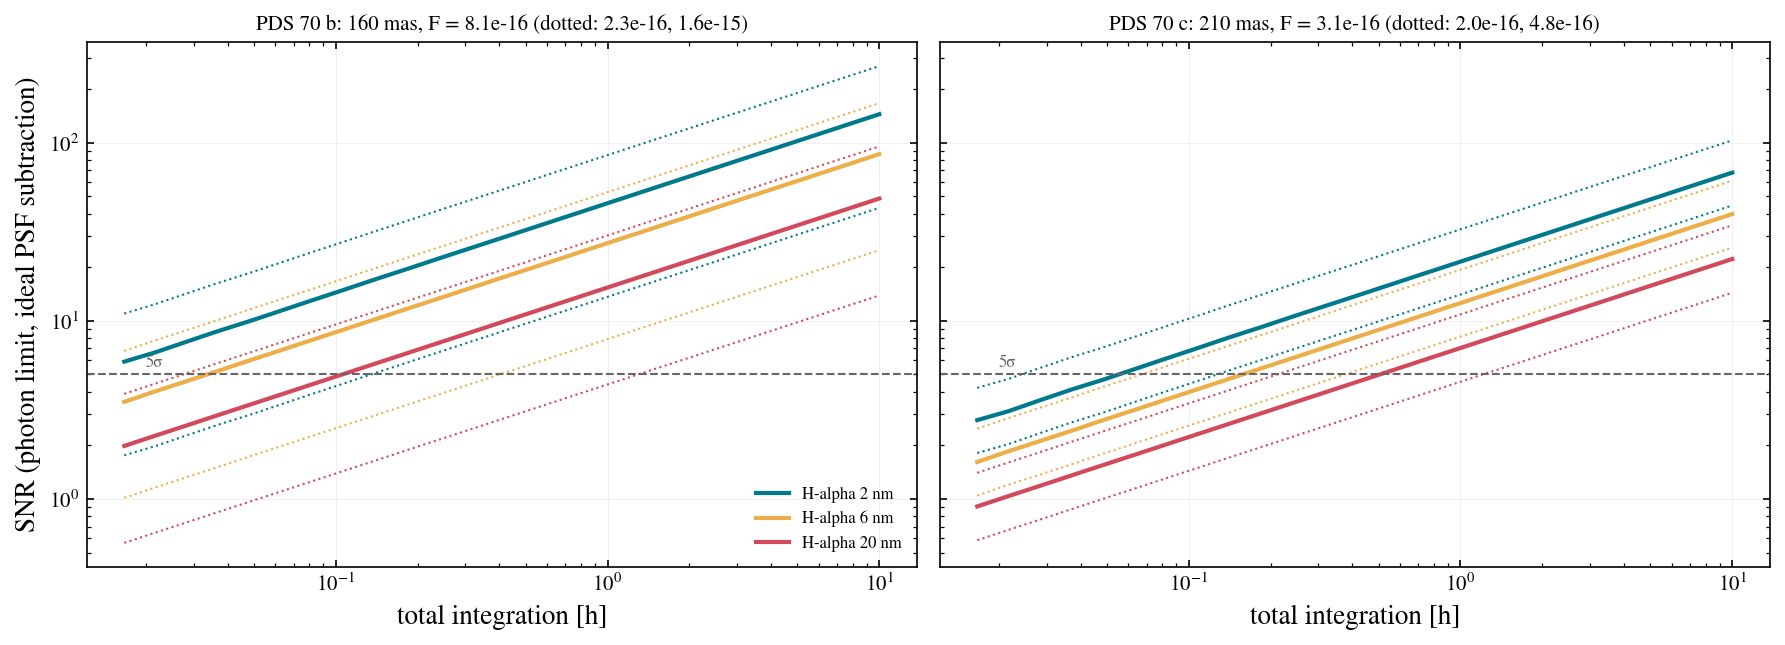

In [6]:
T_GRID = np.logspace(np.log10(60), np.log10(10 * 3600), 25)
rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, (name, pl) in zip(axes, PLANETS.items()):
    for f in FILTERS:
        inst = INST[f]
        for key, ls in [('flux', '-'), ('flux_lo', ':'), ('flux_hi', ':')]:
            snr = np.array([contrast_curve(inst, REQ_JIT, 1.0, [pl['sep_mas']], T, planet_rate=inst.line_rate(pl[key]))['snr'][0]
                            for T in T_GRID])
            ax.plot(T_GRID / 3600, snr, ls, color=FCOL[f], lw=2 if ls == '-' else 1, label=FLAB[f] if ls == '-' else None)
            if key == 'flux':
                for T in [600.0, 3600.0, 5 * 3600.0]:
                    cc = contrast_curve(inst, REQ_JIT, 1.0, [pl['sep_mas']], T, planet_rate=inst.line_rate(pl['flux']))
                    ccS = contrast_curve(inst, REQ_JIT, S_REQ, [pl['sep_mas']], T, planet_rate=inst.line_rate(pl['flux']))
                    rows.append(dict(planet=name, filter=FLAB[f], total_time_s=T, snr_S1=cc['snr'][0], snr_Sreq=ccS['snr'][0],
                                     raw_ratio_S1=(inst.line_rate(pl['flux']) / inst.star_rate) / cc['raw'][0],
                                     r_ap_px=cc['r_ap_px'][0], n_frames=cc['n_frames']))
    ax.axhline(5, color='0.4', ls='--', lw=1); ax.text(0.02, 5.5, '5σ', color='0.4', fontsize=8)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('total integration [h]')
    ax.set_title(f"PDS 70 {name}: {pl['sep_mas']:.0f} mas, F = {pl['flux']:.1e} (dotted: {pl['flux_lo']:.1e}, {pl['flux_hi']:.1e})",
                 fontsize=10)
axes[0].set_ylabel('SNR (photon limit, ideal PSF subtraction)'); axes[0].legend(fontsize=8, loc='lower right')
fig.tight_layout(); savefig(fig, 'fig04_pds70_snr_vs_time')
PDS = Table(rows)
for c in ['snr_S1', 'snr_Sreq', 'raw_ratio_S1']: PDS[c].format = '%.1f'
PDS.write(os.path.join(OUT, 'pds70_snr.ecsv'), format='ascii.ecsv', overwrite=True)
print('raw_ratio = planet flux / stellar light in the same aperture (>1: visible without subtraction)')
PDS.pprint(max_lines=40, max_width=200)

## 5. Generic sensitivity: what line flux is detectable, for which hosts

Young stars in the nearby star-forming regions (Taurus, Lupus, Upper Sco, 100-160 pc) span $G \approx 9$-13.
The 5σ line-flux limit in 1 h (photon limit, ideal subtraction, baseline PSF) as a function of separation,
for three host brightnesses and the three filters. Brighter hosts are worse in two ways: more stellar light
in the aperture and shorter frames, hence more read noise.

grid in 5 s
    filter    host_G sep_mas flux_lim_5sig_1h r_ap_px      t_frame_s     
------------- ------ ------- ---------------- ------- -------------------
 H-alpha 2 nm    9.0   100.0         4.81e-16     1.5  0.6904960240886284
 H-alpha 2 nm    9.0   200.0         2.37e-16     2.0  0.6904960240886284
 H-alpha 2 nm    9.0   400.0         1.97e-16     2.0  0.6904960240886284
 H-alpha 2 nm   11.0   100.0         1.91e-16     1.5   4.356735377330923
 H-alpha 2 nm   11.0   200.0         9.43e-17     2.0   4.356735377330923
 H-alpha 2 nm   11.0   400.0         7.86e-17     2.0   4.356735377330923
 H-alpha 2 nm   13.0   100.0         7.62e-17     1.5  27.489141842836364
 H-alpha 2 nm   13.0   200.0         3.76e-17     2.0  27.489141842836364
 H-alpha 2 nm   13.0   400.0         3.14e-17     2.0  27.489141842836364
 H-alpha 6 nm    9.0   100.0         8.43e-16     1.5 0.22455339046851114
 H-alpha 6 nm    9.0   200.0         4.15e-16     2.0 0.22455339046851114
 H-alpha 6 nm    9.0   400

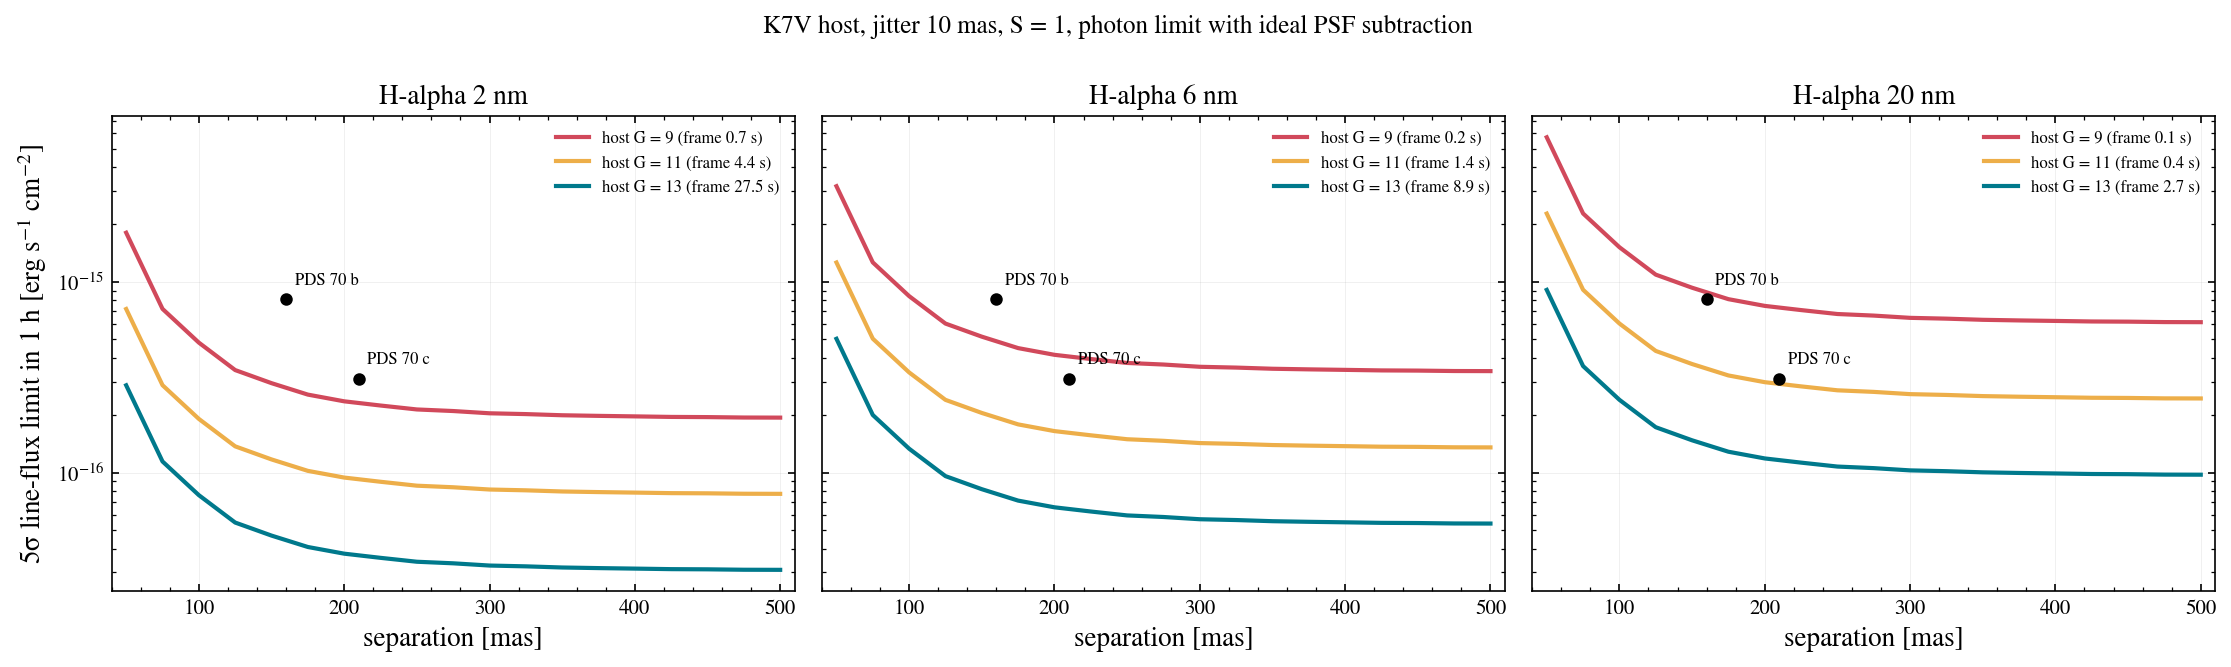

In [7]:
HOST_MAGS = [9.0, 11.0, 13.0]
SEPS_G = np.arange(50.0, 501.0, 25.0)
t0 = time.time()
rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, f in zip(axes, FILTERS):
    for m, col in zip(HOST_MAGS, [RED, AMBER, TEAL]):
        inst = Instrument(f, HOST_SPT, m)
        per_1e16 = inst.line_rate(1e-16) / inst.star_rate
        cc = contrast_curve(inst, REQ_JIT, 1.0, SEPS_G, 3600.0)
        flim = cc['contrast'] / per_1e16 * 1e-16
        ax.plot(SEPS_G, flim, color=col, label=f'host G = {m:.0f} (frame {cc["t_frame_s"]:.1f} s)')
        for s, fl, rap in zip(SEPS_G, flim, cc['r_ap_px']):
            rows.append(dict(filter=FLAB[f], host_G=m, sep_mas=s, flux_lim_5sig_1h=fl, r_ap_px=rap, t_frame_s=cc['t_frame_s']))
    for name, pl in PLANETS.items():
        ax.plot(pl['sep_mas'], pl['flux'], 'o', color='k', ms=5)
        ax.text(pl['sep_mas'] + 6, pl['flux'] * 1.2, f'PDS 70 {name}', fontsize=8)
    ax.set_yscale('log'); ax.set_xlim(40, 510); ax.set_xlabel('separation [mas]'); ax.set_title(FLAB[f])
    ax.legend(fontsize=8, loc='upper right')
axes[0].set_ylabel('5σ line-flux limit in 1 h [erg s$^{-1}$ cm$^{-2}$]')
fig.suptitle(f'{HOST_SPT} host, jitter 10 mas, S = 1, photon limit with ideal PSF subtraction', y=1.0)
fig.tight_layout(); savefig(fig, 'fig05_fluxlimit_grid')
GRID = Table(rows); GRID['flux_lim_5sig_1h'].format = '%.2e'
GRID.write(os.path.join(OUT, 'fluxlimit_grid.ecsv'), format='ascii.ecsv', overwrite=True)
print(f'grid in {time.time() - t0:.0f} s')
GRID[np.isin(GRID['sep_mas'], [100.0, 200.0, 400.0])].pprint(max_lines=40)

## 6. Summary and caveats

**Filter.** The 2 nm filter is the right one: the planet is a line, so its signal is the same in every filter,
while the stellar continuum drops with bandwidth. Two regimes:
* *Photon-limited* (ideal subtraction): the noise is the square root of the stellar light, and the frame time
  shrinks with the star's brightness so the read-noise term scales the same way. The line-flux limit therefore
  improves only as $\sqrt{\rm bandwidth}$: 2 nm beats 20 nm by 3.1x and 6 nm by 1.7x.
* *Systematics-limited* (PSF-subtraction residuals, which scale with the stellar light itself): the gain is the
  full bandwidth ratio, ~10x over 20 nm, ~3x over 6 nm. This is the regime a real observation will be in
  (next notebook), so the narrow filter's advantage is the large one.
Peak throughput is nearly identical for the three filters in the ETC's EOL curves, so nothing is lost in the
core.

**PDS 70.** At the photon limit with an ideal PSF subtraction, both planets are detectable in the 2 nm filter
within an hour (Table above): the jitter-smeared Airy wing at 160-210 mas is a few $10^{-5}$ of the stellar
flux per pixel, bright but countable. Planet b is within a factor of a few of the raw (no-subtraction)
threshold in the 2 nm band. The photon limit itself depends on the detector gain mode at the tens-of-percent
level (read noise and usable well; printed in section 3). The real limit will therefore be
**PSF-subtraction systematics**, not photons; that is what `halpha_hci_jitter_strehl.ipynb` quantifies.

**What this does not include.**
* Any PSF-subtraction residual (jitter or Strehl changes between science and reference, polarisation,
  colour mismatch between host and reference star); noise from the reference itself.
* The host's own H-alpha emission: an accreting classical T Tauri host with EW of tens of Å would more
  than double the stellar light in the 2 nm band. PDS 70 is a weak-line T Tauri star; `HOST_HA_EW_A` is a
  knob for other targets.
* Near-core scattered light: the FRED map is flat inside 1.4" by construction and puts the halo five orders
  of magnitude below the Airy wing here, but it has no information on that scale. Micro-roughness scattering
  at 0.1-0.5" is the one instrument property this analysis cannot bound.
* The PSF is monochromatic at the effective wavelength (fine for a 2 nm band), unobscured Airy (the ETC's
  model), and static; the planet is unresolved with a 2 Å line width.
* Saturation is treated with a half-well rule on the peak pixel; no bleeding, persistence or nonlinearity.
  Readout duty cycle is not modelled: a 16-bit full-frame IMX455 read takes a few tenths of a second, so the
  0.8 s frames of the 20 nm filter lose of order 30% of the time and the 2 nm filter a few percent, which
  widens the 2 nm advantage. Bright hosts in any filter need a sub-array readout.